In [136]:
from arcgis.gis import GIS
from arcgis.apps.itemgraph import ItemGraph, create_dependency_graph

<User username:tkinlaw_EsriEdDelivery>
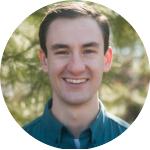

In [137]:
gis = GIS('Home')
gis.users.me

In [138]:
targetItem = gis.content.get('9febb2dd3d9e402fb7d26169f466c33f')
targetItem

<Item title:"DC Transportation Experience_finished" type:Web Experience owner:tkinlaw_EsriEdDelivery>

In [139]:
#This is a top-down approach
graph = create_dependency_graph(gis, [targetItem])
graph

In [140]:
graph.all_items(out_format="item")

[<Item title:"DC Transportation Experience_finished" type:Web Experience owner:tkinlaw_EsriEdDelivery>,
 <Item title:"DC Transportation FedGIS 2026" type:Web Map owner:tkinlaw_EsriEdDelivery>,
 <Item title:"DC Transportation_WFL1" type:Feature Layer Collection owner:tkinlaw_EsriEdDelivery>,
 <Item title:"DC Transportation_WFL1" type:Service Definition owner:tkinlaw_EsriEdDelivery>,
 <Item title:"Dark Gray Canvas Base" type:Vector Tile Layer owner:esri_vector>,
 <Item title:"Metro_Stations_Regional" type:Feature Layer Collection owner:tkinlaw_EsriEdDelivery>,
 <Item title:"Metro_Stations_Regional" type:Service Definition owner:tkinlaw_EsriEdDelivery>,
 <Item title:"Dark Gray Canvas Reference" type:Vector Tile Layer owner:esri_vector>]

In [141]:
targetNode = graph.get_node(targetItem.id)
print(targetNode.item.title, targetNode.item.type)

DC Transportation Experience_finished Web Experience


In [142]:
# contains() = items immediately used/referenced by the experience builder item
nodes = targetNode.contains()
if nodes:
    print(f"This item contains {len(nodes)} item(s):")
    for node in nodes:
        print("\t", node.item.title, "(" + node.item.type + ")")
else:
    print("This item does not contain other items directly.")

This item contains 1 item(s):
	 DC Transportation FedGIS 2026 (Web Map)


In [143]:
# requires() = every item needed for the experience builder to exist
nodes = targetNode.requires()
if nodes:
    print(f"This item requires {len(nodes)} item(s):")
    for node in nodes:
        print("\t", node.item.title, "(" + node.item.type + ")")
else:
    print("This item requires no items. It does not have deep dependencies.")

This item requires 7 item(s):
	 Dark Gray Canvas Reference (Vector Tile Service)
	 DC Transportation_WFL1 (Service Definition)
	 DC Transportation_WFL1 (Feature Service)
	 Dark Gray Canvas Base (Vector Tile Service)
	 Metro_Stations_Regional (Service Definition)
	 Metro_Stations_Regional (Feature Service)
	 DC Transportation FedGIS 2026 (Web Map)


In [144]:
# contained_by() = items in the graph that immediately use/reference this experience builder item
nodes = targetNode.contained_by()
if nodes:
    print(f"This item is contained by {len(nodes)} item(s):")
    for node in nodes:
        print("\t", node.item.title, "(" + node.item.type + ")")
else:
    print("This item is not contained by other items. It is not a dependency.")

This item is not contained by other items. It is not a dependency.


In [145]:
# required_by() = every item in the graph that needs this experience builder item to exist
nodes = targetNode.required_by()
if nodes:
    print(f"This item is a deep dependency and required by {len(nodes)} item(s):")
    for node in nodes:
        print("\t", node.item.title, "(" + node.item.type + ")")
else:
    print("This item is not required by any items. It is not a deep dependency.")

This item is not required by any items. It is not a deep dependency.
